In [1]:
from pathlib import Path
import pandas as pd
import h5py
import scipy.io
import numpy as np

mat_path = Path("../data/EEG_recordings/EEG_DDvMMR_photodiode_test_20260622.mat")
if not mat_path.exists():  # Supports kernels started from the repository root.
    mat_path = Path("data/EEG_recordings/EEG_DDvMMR_photodiode_test_20260622.mat")
print(f"Loading MAT file: {mat_path}")

try:
    mat = scipy.io.loadmat(mat_path, squeeze_me=True, struct_as_record=False)
except NotImplementedError:
    # MATLAB v7.3 files use HDF5, which scipy.io.loadmat cannot read.
    with h5py.File(mat_path, "r") as h5_file:
        mat = {key: h5_file[key][()] for key in h5_file.keys()}
    print("Loaded MATLAB v7.3/HDF5 file with h5py.")

keys = [k for k in mat.keys() if not k.startswith("__")]
print("MAT variables:", keys)
print(f"Number of variables loaded: {len(keys)}")

frames = {}
for key in keys:
    value = mat[key]
    if isinstance(value, np.ndarray):
        if value.ndim == 2:
            frames[key] = pd.DataFrame(value)
        elif value.ndim == 1:
            frames[key] = pd.DataFrame(value, columns=[key])
        else:
            print(f"Skipping {key}: ndarray with ndim={value.ndim}")
    elif np.isscalar(value) or isinstance(value, (str, bytes)):
        frames[key] = pd.DataFrame({key: [value]})
    else:
        print(f"Skipping {key}: unsupported type {type(value)}")

print("\nImported DataFrames:")
for key, df in frames.items():
    print(f"- {key}: shape={df.shape}, columns={list(df.columns)[:10]}")
    print(df.head())
    print()

if not frames:
    print("No suitable variables were converted to DataFrames.")

Loading MAT file: ../data/EEG_recordings/EEG_DDvMMR_photodiode_test_20260622.mat
Loaded MATLAB v7.3/HDF5 file with h5py.
MAT variables: ['EEG_data']
Number of variables loaded: 1

Imported DataFrames:
- EEG_data: shape=(51088, 67), columns=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
         0             1             2             3             4   \
0  0.000000 -353033.78125 -355399.50000 -352503.25000 -353591.81250   
1  0.000833 -353030.90625 -355399.09375 -352500.37500 -353573.78125   
2  0.001667 -353032.31250 -355400.40625 -352501.78125 -353596.37500   
3  0.002500 -353030.93750 -355400.40625 -352500.40625 -353639.46875   
4  0.003333 -353031.31250 -355400.75000 -352500.78125 -353614.75000   

             5             6            7             8             9   ...  \
0 -352827.96875 -355053.75000 -355143.9375 -351731.34375 -354372.28125  ...   
1 -352825.09375 -355079.18750 -355134.2500 -351728.46875 -354378.28125  ...   
2 -352826.50000 -355041.18750 -355137.3125 -351729.87500 -354367.

In [5]:
import h5py
import numpy as np
import pandas as pd
from pathlib import Path

mat_path = Path("../data/EEG_recordings/EEG_DDvMMR_photodiode_test_20260622.mat")
if not mat_path.exists():  # Supports kernels started from the repository root.
    mat_path = Path("data/EEG_recordings/EEG_DDvMMR_photodiode_test_20260622.mat")

with h5py.File(mat_path, "r") as f:
    eeg_array = f["EEG_data"][()]  # shape=(26881, 67), float64

df_eeg = pd.DataFrame(eeg_array)
df_eeg.columns = [f"ch_{i}" for i in range(df_eeg.shape[1])]

df_eeg.info()


<class 'pandas.DataFrame'>
RangeIndex: 417330 entries, 0 to 417329
Data columns (total 67 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ch_0    417330 non-null  float64
 1   ch_1    417330 non-null  float64
 2   ch_2    417330 non-null  float64
 3   ch_3    417330 non-null  float64
 4   ch_4    417330 non-null  float64
 5   ch_5    417330 non-null  float64
 6   ch_6    417330 non-null  float64
 7   ch_7    417330 non-null  float64
 8   ch_8    417330 non-null  float64
 9   ch_9    417330 non-null  float64
 10  ch_10   417330 non-null  float64
 11  ch_11   417330 non-null  float64
 12  ch_12   417330 non-null  float64
 13  ch_13   417330 non-null  float64
 14  ch_14   417330 non-null  float64
 15  ch_15   417330 non-null  float64
 16  ch_16   417330 non-null  float64
 17  ch_17   417330 non-null  float64
 18  ch_18   417330 non-null  float64
 19  ch_19   417330 non-null  float64
 20  ch_20   417330 non-null  float64
 21  ch_21   417330 non-nu

<Axes: xlabel='ch_0'>

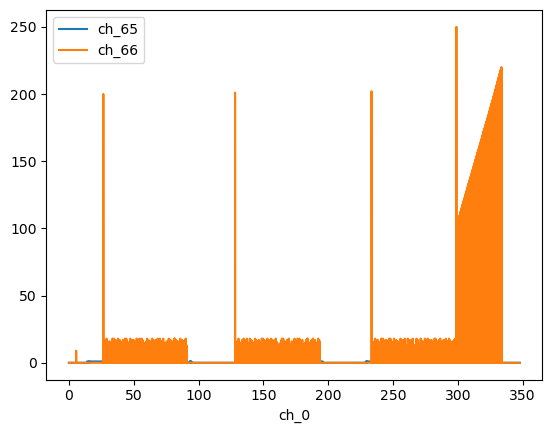

In [6]:
df_eeg.plot(x="ch_0", y=["ch_65","ch_66"], kind="line")

In [7]:
import h5py
import numpy as np
from pathlib import Path

mat_path = Path("../data/EEG_recordings/EEG_DDvMMR_photodiode_test_20260622.mat")
if not mat_path.exists():
    mat_path = Path("data/EEG_recordings/EEG_DDvMMR_photodiode_test_20260622.mat")

with h5py.File(mat_path, "r") as f:
    print("HDF5 keys:", list(f.keys()))
    eeg = f["EEG_data"][()]
print("raw EEG_data shape:", eeg.shape)

# orient to (samples, channels): the long axis is time
if eeg.ndim == 2 and eeg.shape[0] < eeg.shape[1]:
    eeg = eeg.T
n_samp, n_ch = eeg.shape
print(f"oriented: {n_samp} samples x {n_ch} channels")

# --- column 0 assumed to be the To File time row ---------------------------
t = eeg[:, 0]
dt = np.diff(t)
fs = 1.0 / np.median(dt)
print("\n--- col 0 (time) ---")
print(f"  span={t[-1]-t[0]:.3f}s  monotonic={np.all(dt>0)}  "
      f"fs≈{fs:.2f} Hz  dt min/max={dt.min():.2e}/{dt.max():.2e}")

# --- identify marker-like vs analog among the last channels ----------------
print("\n--- last 6 channels ---")
for c in range(max(1, n_ch - 6), n_ch):
    col = eeg[:, c]
    uniq = np.unique(col)
    print(f"  ch_{c}: min={col.min():.3g} max={col.max():.3g} "
          f"n_unique={uniq.size} n_nonzero={np.count_nonzero(col)}")
    if uniq.size <= 25:
        vals, cnts = np.unique(col, return_counts=True)
        print("      values:counts =",
              {int(v): int(n) for v, n in zip(vals, cnts)})

# --- marker channel: event list + plateau widths ---------------------------
MARKER_CH = 66          # adjust from the summary above if needed
m = eeg[:, MARKER_CH]
prev = np.concatenate([[0.0], m[:-1]])
edges = np.where((m != 0) & (m != prev))[0]
print(f"\n--- ch_{MARKER_CH} markers: {edges.size} events ---")
for i in edges:
    j = i
    while j < n_samp and m[j] == m[i]:
        j += 1
    print(f"  t={t[i]:8.3f}s  code={int(m[i]):4d}  held {j-i} samp "
          f"(~{(j-i)/fs*1000:.0f} ms)")

# --- photodiode channel: count the flashes ---------------------------------
PHOTO_CH = 65           # adjust if the summary shows the analog channel elsewhere
p = eeg[:, PHOTO_CH]
thr = (p.max() + p.min()) / 2
xings = np.where((p[:-1] < thr) & (p[1:] >= thr))[0]
print(f"\n--- ch_{PHOTO_CH} photodiode: min={p.min():.3g} max={p.max():.3g} "
      f"upward crossings={xings.size} ---")
if xings.size:
    print("  first crossings (s):", np.round(t[xings[:8]], 3))
    print("  last  crossings (s):", np.round(t[xings[-3:]], 3))

# --- does the rig keep running after the last marker? ----------------------
eeg_block = eeg[:, 1:65] if n_ch >= 65 else eeg[:, 1:]
print("\n--- end-of-data ---")
print(f"  total time {t[-1]-t[0]:.3f}s")
if edges.size:
    print(f"  last marker at {t[edges[-1]]:.3f}s "
          f"({t[-1]-t[edges[-1]]:.3f}s of recording after it)")
print(f"  EEG std, last 2000 samp: {eeg_block[-2000:].std():.4g} "
      f"(~0 ⇒ amp/recording flat-lined; nonzero ⇒ still acquiring)")

HDF5 keys: ['EEG_data']
raw EEG_data shape: (417330, 67)
oriented: 417330 samples x 67 channels

--- col 0 (time) ---
  span=347.774s  monotonic=True  fs≈1200.00 Hz  dt min/max=8.33e-04/8.33e-04

--- last 6 channels ---
  ch_61: min=-3.58e+05 max=-3.57e+05 n_unique=13763 n_nonzero=417330
  ch_62: min=-3.56e+05 max=-3.55e+05 n_unique=19148 n_nonzero=417330
  ch_63: min=-3.55e+05 max=-3.54e+05 n_unique=23059 n_nonzero=417330
  ch_64: min=-3.56e+05 max=-3.56e+05 n_unique=3094 n_nonzero=417330
  ch_65: min=0 max=1 n_unique=2 n_nonzero=58441
      values:counts = {0: 358889, 1: 58441}
  ch_66: min=0 max=250 n_unique=133 n_nonzero=9015

--- ch_66 markers: 666 events ---
  t=   5.604s  code=   9  held 1 samp (~1 ms)
  t=  26.568s  code= 200  held 1 samp (~1 ms)
  t=  27.728s  code=  10  held 23 samp (~19 ms)
  t=  28.097s  code=  16  held 12 samp (~10 ms)
  t=  28.432s  code=  17  held 13 samp (~11 ms)
  t=  28.758s  code=  13  held 15 samp (~12 ms)
  t=  29.089s  code=  18  held 13 samp (~11

In [8]:
import h5py
import numpy as np
import pandas as pd
from pathlib import Path

mat_path = Path("../data/EEG_recordings/EEG_DDvMMR_photodiode_test_20260622.mat")
if not mat_path.exists():
    mat_path = Path("data/EEG_recordings/EEG_DDvMMR_photodiode_test_20260622.mat")

with h5py.File(mat_path, "r") as f:
    eeg = f["EEG_data"][()]
if eeg.ndim == 2 and eeg.shape[0] < eeg.shape[1]:
    eeg = eeg.T

t       = eeg[:, 0]
markers = eeg[:, 66]
photo   = eeg[:, 65]
n = eeg.shape[0]

SCHEDULING = ["PRE_FLIP", "ON_FLIP", "POST_FLIP"]
LUMINANCE  = [0.25, 0.50, 1.00]
FLASH_CODES = set(range(10, 19))
MATCH_WINDOW = 0.080   # s; << inter-flash gap (~0.33 s), > any plausible delay

def decode(code):
    c = int(code) - 10
    return SCHEDULING[c // 3], LUMINANCE[c % 3]

# --- flash-marker leading edges (onset of each plateau) --------------------
prev_m = np.concatenate([[0.0], markers[:-1]])
m_edge_idx = np.where((np.isin(markers, list(FLASH_CODES))) &
                      (markers != prev_m))[0]
marker_t    = t[m_edge_idx]
marker_code = markers[m_edge_idx].astype(int)
print(f"flash-marker onsets: {m_edge_idx.size}")

# --- photodiode rising edges (square appears) ------------------------------
d_edge_idx = np.where((photo[:-1] == 0) & (photo[1:] == 1))[0] + 1
diode_t = t[d_edge_idx]
print(f"photodiode rising edges: {diode_t.size}")

# --- match each diode edge to the nearest flash marker in time -------------
rows = []
for dt_ in diode_t:
    k = np.argmin(np.abs(marker_t - dt_))
    gap = dt_ - marker_t[k]                 # +ve: light after marker (expected)
    if abs(gap) <= MATCH_WINDOW:
        sched, lum = decode(marker_code[k])
        rows.append({"code": int(marker_code[k]), "scheduling": sched,
                     "luminance": lum, "marker_t": marker_t[k],
                     "diode_t": dt_, "delay_ms": gap * 1000.0})

df = pd.DataFrame(rows)
print(f"\nmatched diode->marker pairs: {len(df)} "
      f"(unmatched diode edges = alignment screens / dim flashes)")

if not df.empty:
    print("\n=== marker -> square delay (ms), by scheduling x luminance ===")
    summary = (df.groupby(["scheduling", "luminance"])["delay_ms"]
                 .agg(n="count", mean="mean", median="median", sd="std")
                 .round(2))
    print(summary)

    print("\n=== HEADLINE: ON_FLIP x 1.00 (code 15) ===")
    h = df[(df.scheduling == "ON_FLIP") & (df.luminance == 1.00)]["delay_ms"]
    if h.size:
        print(f"  n={h.size}  mean={h.mean():.2f} ms  median={h.median():.2f} "
              f"ms  sd={h.std():.2f} ms  min/max={h.min():.2f}/{h.max():.2f}")
    else:
        print("  no matches (diode never caught a bright ON_FLIP flash)")

    print("\n=== effect of scheduling (pooled luminance) ===")
    print(df.groupby("scheduling")["delay_ms"]
            .agg(n="count", mean="mean", sd="std").round(2))

# --- diode catch-rate per luminance: how often the TTL tripped -------------
print("\n=== diode catch-rate by code (did the TTL fire for this flash?) ===")
for code in sorted(FLASH_CODES):
    sched, lum = decode(code)
    issued = int(np.sum(marker_code == code))
    caught = int(np.sum(df["code"] == code)) if not df.empty else 0
    rate = caught / issued if issued else 0.0
    print(f"  code {code} ({sched:9s} {lum:.2f}): "
          f"{caught:3d}/{issued:3d} caught ({rate:5.1%})")

flash-marker onsets: 540
photodiode rising edges: 119

matched diode->marker pairs: 56 (unmatched diode edges = alignment screens / dim flashes)

=== marker -> square delay (ms), by scheduling x luminance ===
                      n   mean  median     sd
scheduling luminance                         
ON_FLIP    0.25       6   7.36   24.58  49.77
           0.50       9   9.63    9.17  49.56
           1.00       7  -8.45  -31.67  58.29
POST_FLIP  0.25       4   7.92  -11.25  47.69
           0.50       4 -27.92  -47.50  58.88
           1.00       7  -6.43   -4.17  53.70
PRE_FLIP   0.25       7  17.14   24.17  44.95
           0.50       7  -6.79  -34.17  50.93
           1.00       5 -25.83  -21.67  44.58

=== HEADLINE: ON_FLIP x 1.00 (code 15) ===
  n=7  mean=-8.45 ms  median=-31.67 ms  sd=58.29 ms  min/max=-77.50/76.67

=== effect of scheduling (pooled luminance) ===
             n  mean     sd
scheduling                 
ON_FLIP     22  3.26  50.64
POST_FLIP   15 -8.33  51.51
PRE_FL

In [9]:
import h5py, numpy as np
from pathlib import Path

mat_path = Path("../data/EEG_recordings/EEG_DDvMMR_photodiode_test_20260622.mat")
if not mat_path.exists():
    mat_path = Path("data/EEG_recordings/EEG_DDvMMR_photodiode_test_20260622.mat")
with h5py.File(mat_path, "r") as f:
    eeg = f["EEG_data"][()]
if eeg.ndim == 2 and eeg.shape[0] < eeg.shape[1]:
    eeg = eeg.T
t, photo, markers = eeg[:, 0], eeg[:, 65], eeg[:, 66]
fs = 1.0 / np.median(np.diff(t))

# ON-period durations on the diode channel
rise = np.where((photo[:-1] == 0) & (photo[1:] == 1))[0] + 1
fall = np.where((photo[:-1] == 1) & (photo[1:] == 0))[0] + 1
print(f"rises={rise.size} falls={fall.size} fs={fs:.1f}")
if rise.size and fall.size:
    if fall[0] < rise[0]:
        fall = fall[1:]
    k = min(rise.size, fall.size)
    on_ms = (fall[:k] - rise[:k]) / fs * 1000
    print("ON-duration ms: min/median/max =",
          f"{on_ms.min():.0f}/{np.median(on_ms):.0f}/{on_ms.max():.0f}")
    print("ON durations >300ms (merged flashes?):", int(np.sum(on_ms > 300)))
    print("first 15 ON durations:", np.round(on_ms[:15]).astype(int))

# restrict to the FIRST position block only (markers 200..201 bracket it):
m_block_starts = np.where(np.isin(markers, [200, 201, 202, 250]))[0]
print("\nblock/cadence boundary sample indices:", m_block_starts,
      "\ntimes:", np.round(t[m_block_starts], 1))
# count flash markers vs diode rises inside block 1 (200 -> 201)
if m_block_starts.size >= 2:
    b0, b1 = t[m_block_starts[0]], t[m_block_starts[1]]
    fm = np.where(np.isin(markers, list(range(10,19))) &
                  (np.r_[0, markers[:-1]] != markers))[0]
    fm_t = t[fm]
    n_fm = np.sum((fm_t >= b0) & (fm_t < b1))
    n_di = np.sum((t[rise] >= b0) & (t[rise] < b1))
    print(f"\nblock 1 ({b0:.0f}-{b1:.0f}s): {n_fm} flash markers, "
          f"{n_di} diode rises")

rises=119 falls=119 fs=1200.0
ON-duration ms: min/median/max = 30/262/11842
ON durations >300ms (merged flashes?): 5
first 15 ON durations: [  886   622 11842   250   250   250   250   250   250   250   249   265
   264   264   262]

block/cadence boundary sample indices: [ 31882 153788 280115 358651 393652 394021 394372] 
times: [ 26.6 128.2 233.4 298.9 328.  328.4 328.6]

block 1 (27-128s): 180 flash markers, 38 diode rises
